
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_13_Hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Memorias asociativas con redes de Hopfield

## Objetivo

Construir una red de Hopfield capaz de almacenar imágenes binarias y recuperar una imagen original a partir de una versión con ruido.


# Actividades

Para las imágenes dadas, construya un algoritmo que permita recuperar la imagen original a partir de una imagen perturbada.

Debe implementar funciones para:

1. Convertir una imagen binaria en un vector de estados.
2. Calcular la matriz de pesos de Hopfield.
3. Calcular el campo local que siente una neurona.
4. Actualizar el estado de una neurona.
5. Calcular la energía total de la red.
6. Aplicar ruido a una imagen.
7. Recuperar la imagen mediante actualización asincrónica aleatoria.

---

# Modelo de Hopfield

La matriz de pesos se define mediante la regla de Hebb:

$$
w_{ij}=\frac{1}{N}\sum_{\mu=1}^{P}\xi_i^\mu \xi_j^\mu
$$

con:

$$
w_{ii}=0
$$

donde:

- $N$ es el número total de píxeles,
- $P$ es el número de patrones almacenados,
- $\xi^\mu$ es el patrón $\mu$-ésimo.

---

# Campo local

Para una neurona $i$, el campo local es:

$$
h_i=\sum_j w_{ij}s_j
$$

Este campo representa la influencia colectiva que todas las demás neuronas ejercen sobre la neurona $i$.

---

# Regla de actualización

La actualización determinista de Hopfield es:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

Si:

$$
h_i>0
$$

entonces:

$$
s_i=1
$$

Si:

$$
h_i<0
$$

entonces:

$$
s_i=-1
$$

---

# Energía de la red

La energía total del sistema se define como:

$$
E(s)=-\frac{1}{2}\sum_{ij}w_{ij}s_is_j
$$

o equivalentemente:

$$
E(s)=-\frac{1}{2}s^TWs
$$

El proceso de recuperación debe tender a disminuir la energía.

---

# Algoritmo sugerido

Dada una imagen con ruido:

1. Seleccione aleatoriamente un píxel $i$.
2. Calcule el campo local:

$$
h_i=\sum_j w_{ij}s_j
$$

3. Actualice el estado del píxel:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

4. Calcule la nueva energía del sistema:

$$
E(s)=-\frac{1}{2}s^TWs
$$

5. Visite otro píxel aleatoriamente.
6. Repita el proceso hasta que:
   - la imagen deje de cambiar,
   - la energía se estabilice,
   - o se alcance un número máximo de iteraciones.


# Comentario importante

La actualización debe ser preferiblemente **asincrónica y aleatoria**, porque cada vez que se actualiza un píxel, cambia el estado global de la red. Por tanto, el siguiente campo local debe calcularse usando la imagen ya actualizada.

---

# Preguntas guía

1. ¿La energía disminuye durante la recuperación?
2. ¿La red recupera exactamente la imagen original?
3. ¿Qué ocurre si aumenta el nivel de ruido?
4. ¿Qué pasa si se almacenan varias imágenes?
5. ¿Aparecen estados espurios?
6. ¿La recuperación depende del orden en que se actualizan los píxeles?
7. ¿Qué diferencia hay entre actualización sincrónica y asincrónica?

---

# Capacidad de memoria

La capacidad aproximada de una red de Hopfield clásica es:

$$
P_c \approx 0.138N
$$

donde:

- $P_c$ es el número máximo de patrones recuperables,
- $N$ es el número total de neuronas.

Cuando el número de patrones almacenados supera este valor, aparecen errores y estados espurios.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def patrones_balanceados(n, m):
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker

def agregar_ruido(s, frac=0.25, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido

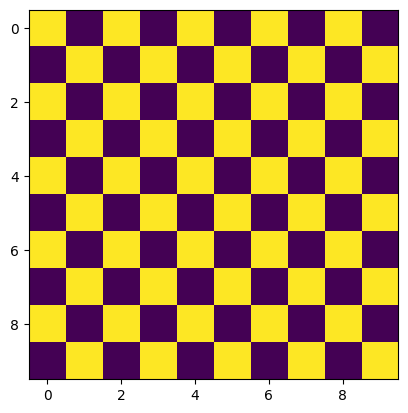

In [ ]:
h, v, d = patrones_balanceados(10, 10)
plt.imshow(d)

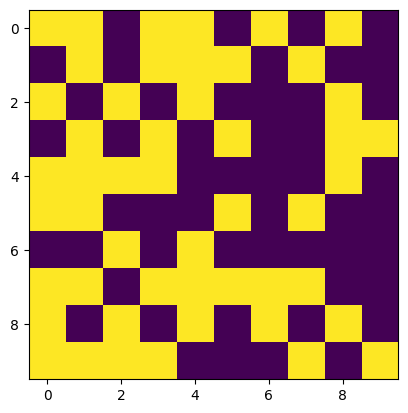

In [ ]:
s_ruido = agregar_ruido(np.concat(d), frac=0.25, seed=10)
plt.imshow(np.reshape(s_ruido, (10, 10)))

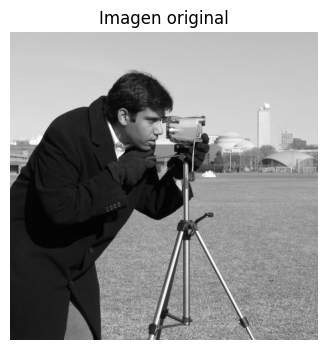

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize
from skimage.color import rgb2gray

img = data.camera()   # imagen 512x512 en escala de grises

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

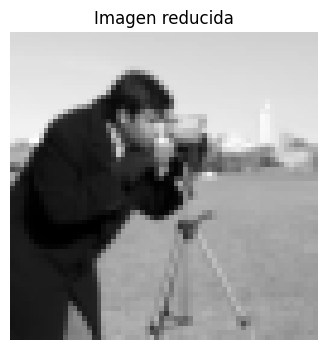

In [ ]:
# ============================================================
# Reducir imagen
# ============================================================

n = 64
m = 64

img_small = resize(img, (n, m), anti_aliasing=True)

plt.figure(figsize=(4,4))
plt.imshow(img_small, cmap="gray")
plt.title("Imagen reducida")
plt.axis("off")
plt.show()

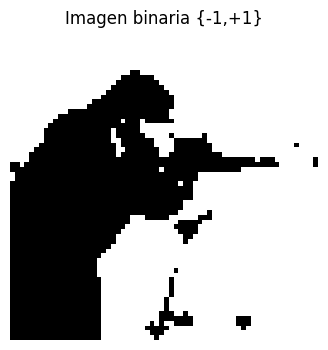

In [ ]:
# ============================================================
# Binarización
# ============================================================

threshold = img_small.mean()

img_bin = np.where(img_small > threshold, 1, -1)

plt.figure(figsize=(4,4))
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binaria {-1,+1}")
plt.axis("off")
plt.show()

In [ ]:
img_bin

array([[ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       ...,
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1]])

In [ ]:
# ============================================================
# Ruido
# ============================================================

def agregar_ruido(s, frac=0.30, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido


frac_ruido = 0.30

s_ruido = agregar_ruido(np.concat(img_bin), frac=frac_ruido, seed=123)


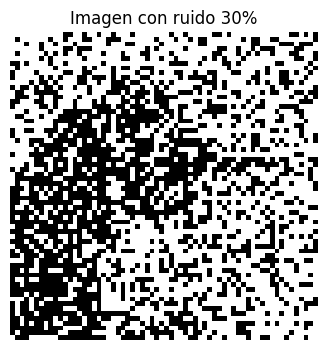

In [ ]:
plt.figure(figsize=(4,4))
plt.imshow(s_ruido.reshape(n, m), cmap="gray")
plt.title(f"Imagen con ruido {frac_ruido*100:.0f}%")
plt.axis("off")
plt.show()

EXPERIMENTO 1: RECUPERACION DE IMAGEN NATURAL (CAMERAMAN)


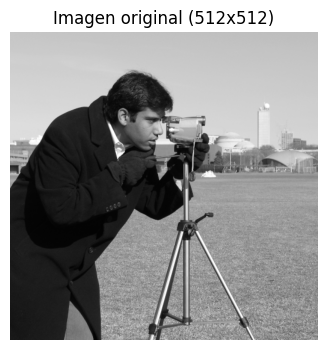

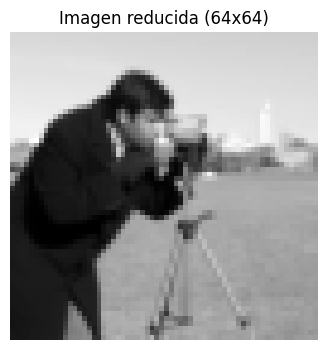

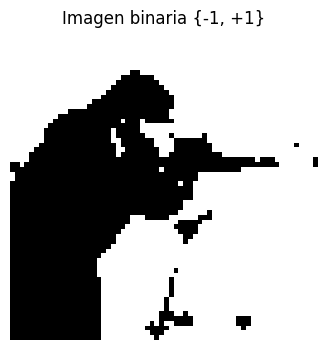

Numero de neuronas: 4096
Matriz de pesos calculada: (4096, 4096)


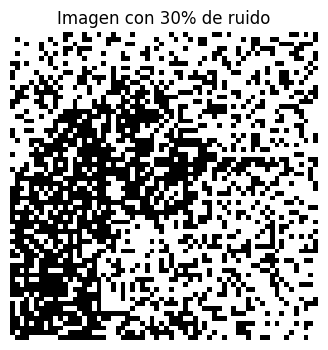

Iniciando recuperacion...
  Energia inicial: -327.82
  Iteraciones maximas: 50000
--------------------------------------------------
  Red estabilizada en iteracion 28304
  Sin cambios durante 4096 actualizaciones consecutivas
  Energia final: -2047.50
  Cambios efectivos realizados: 1228


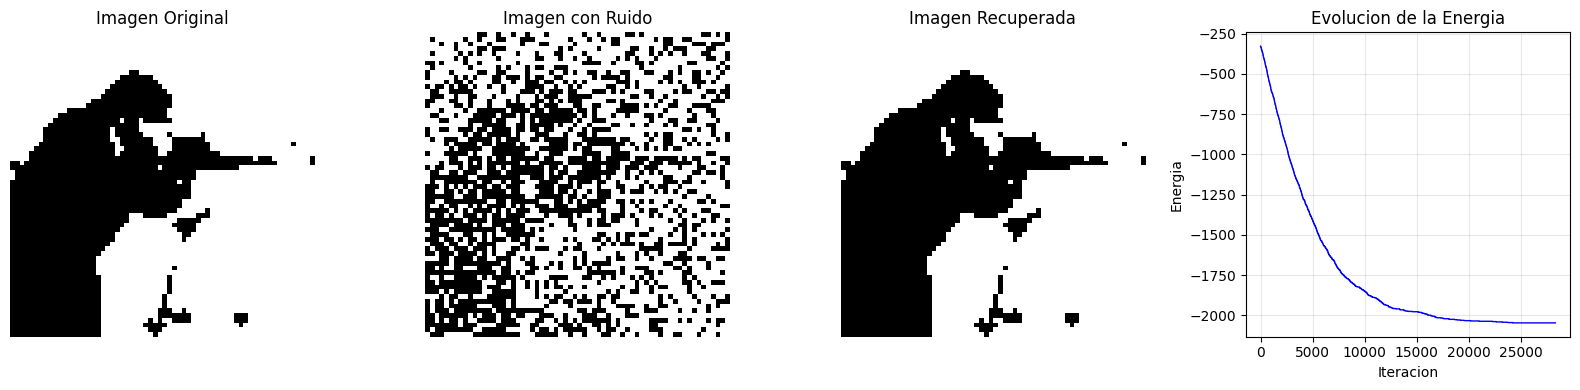


Proporcion de pixeles recuperados correctamente: 1.0000 (100.00%)

Pregunta 1: ¿La energia disminuye durante la recuperacion?
Respuesta: Si. Como se observa en el grafico de evolucion de la energia,
la energia total del sistema disminuye monotonicamente durante el proceso
de actualizacion asincronica, convergiendo a un minimo local que corresponde
al patron almacenado o a un estado espurio cercano.



EXPERIMENTO 2: EFECTO DEL NIVEL DE RUIDO


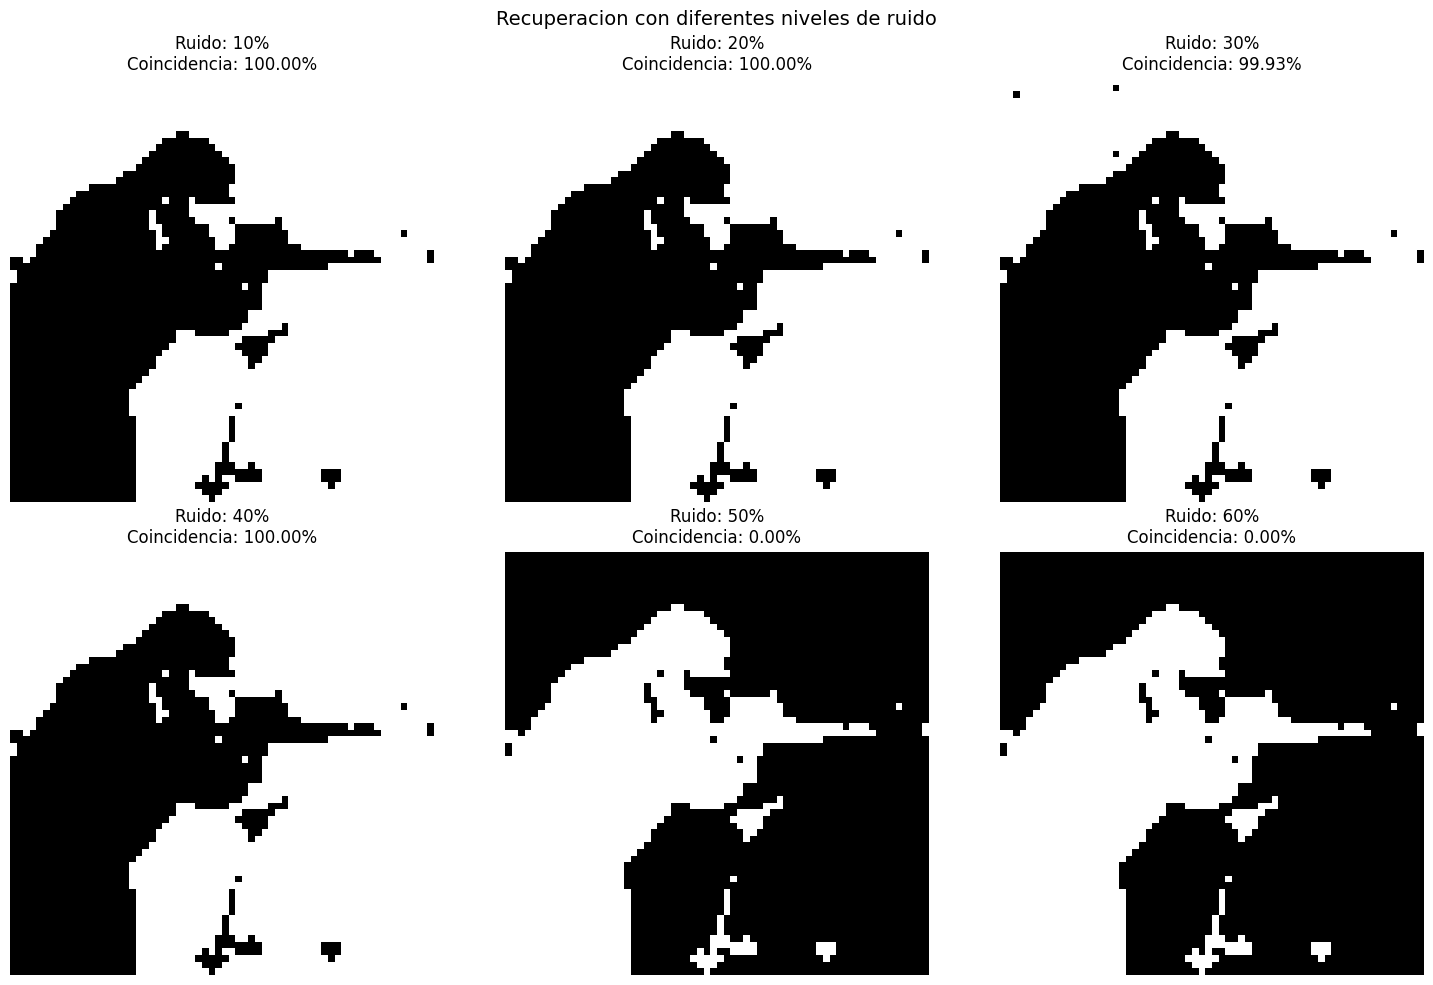


Resultados del experimento con diferentes niveles de ruido:
------------------------------------------------------------
Ruido      Coincidencia    Iteraciones 
------------------------------------------------------------
10        % 1.0000          32304       
20        % 1.0000          32487       
30        % 0.9993          26127       
40        % 1.0000          32039       
50        % 0.0000          34269       
60        % 0.0000          33307       

Pregunta 3: ¿Que ocurre si aumenta el nivel de ruido?
Respuesta: A medida que aumenta el nivel de ruido, la capacidad de
recuperacion disminuye. Con niveles bajos de ruido (10-30%), la red
recupera casi perfectamente el patron original. Con niveles moderados
(40-50%), la recuperacion es parcial. Con niveles altos (>50%), la red
puede converger a estados espurios o no lograr recuperar el patron.



EXPERIMENTO 3: ALMACENAMIENTO DE MULTIPLES PATRONES BALANCEADOS
Numero de neuronas por patron: 1024
Capacidad teorica de memoria:

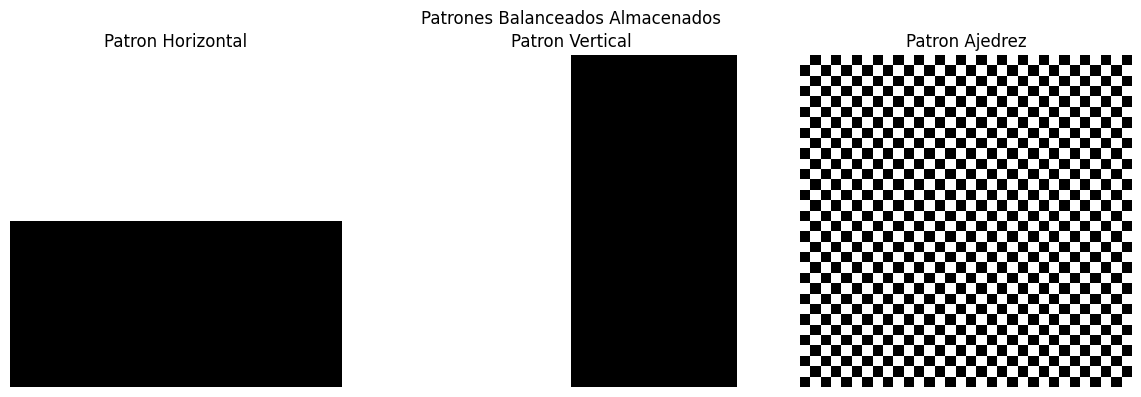


Patron Horizontal:
  Coincidencia: 1.0000 (100.00%)
  Iteraciones hasta estabilizacion: 6803
  Energia final: -510.50

Patron Vertical:
  Coincidencia: 1.0000 (100.00%)
  Iteraciones hasta estabilizacion: 5995
  Energia final: -510.50

Patron Ajedrez:
  Coincidencia: 0.9980 (99.80%)
  Iteraciones hasta estabilizacion: 5261
  Energia final: -506.51


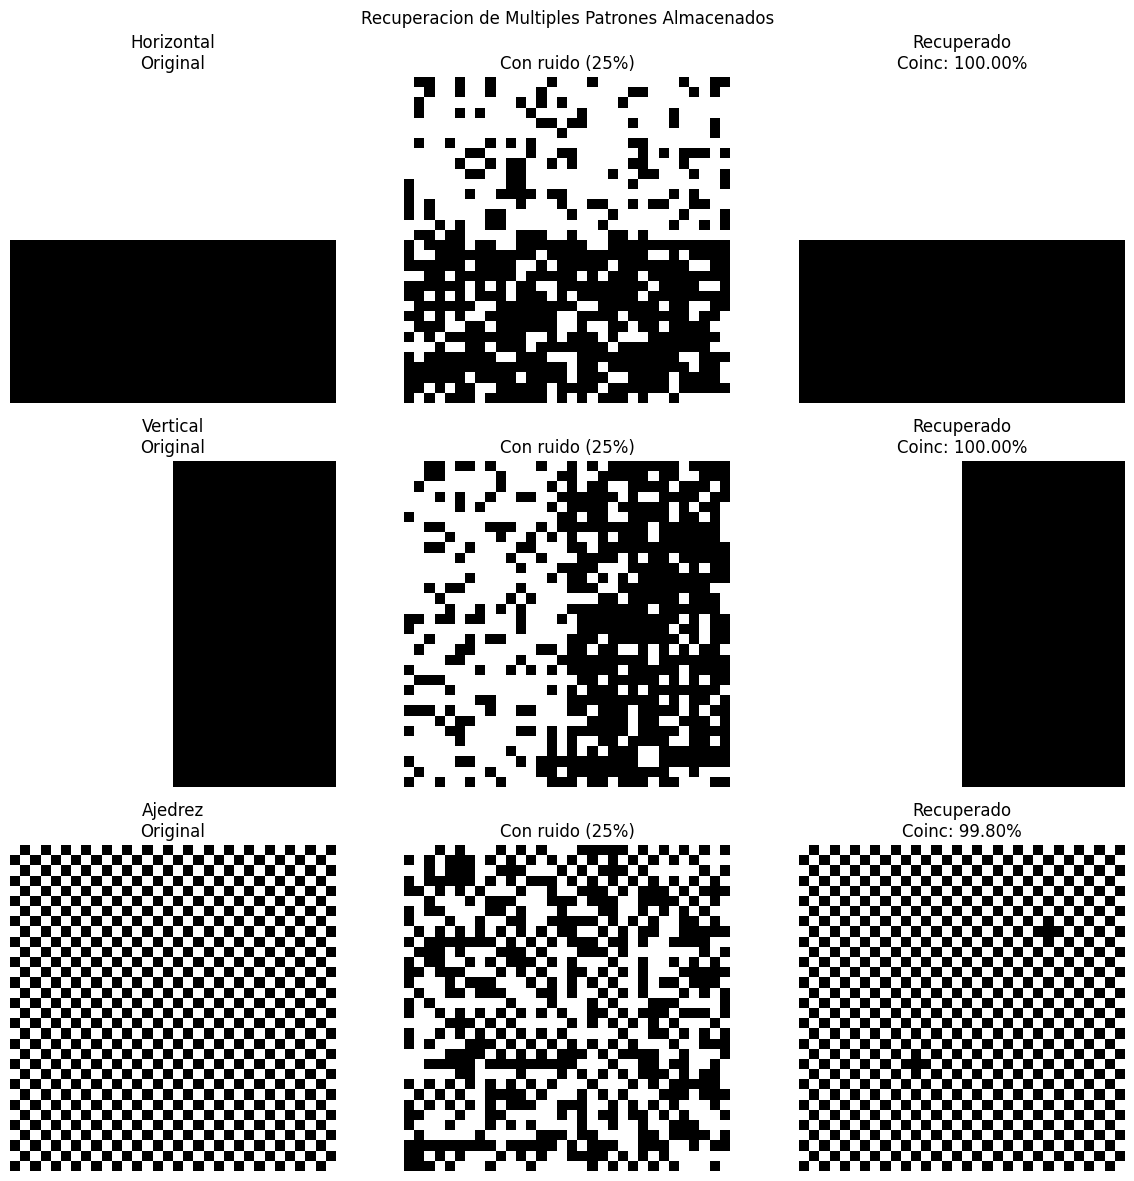


Pregunta 4: ¿Que pasa si se almacenan varias imagenes?
Respuesta: La red de Hopfield puede almacenar multiples patrones, pero
su capacidad es limitada (aproximadamente 0.138N patrones). Al almacenar
varios patrones, pueden aparecer estados espurios (combinaciones no deseadas
de los patrones almacenados) y la calidad de recuperacion puede degradarse.
En este experimento, con 3 patrones de 1024 neuronas, la red los recupera
adecuadamente desde versiones con ruido moderado.



EXPERIMENTO 4: ESTADOS ESPURIOS Y DEPENDENCIA DEL ORDEN DE ACTUALIZACION


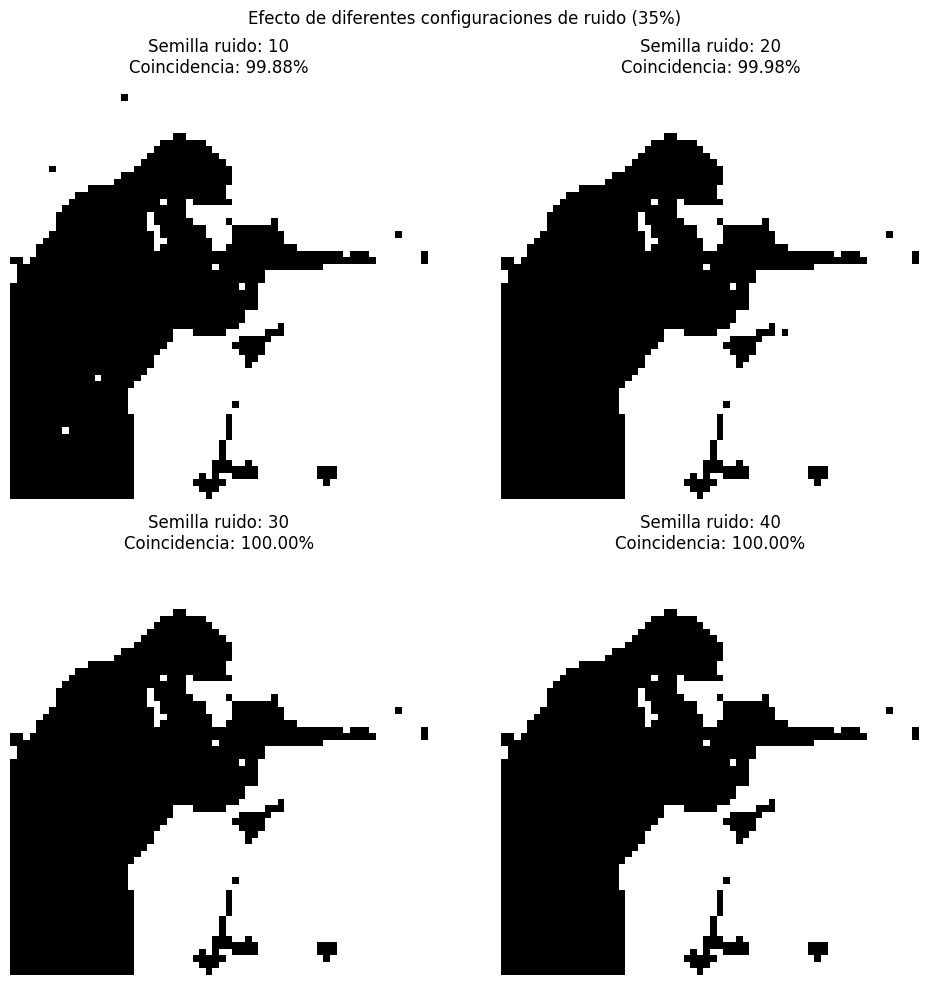

Resultados con diferentes semillas de ruido (35%):
  Semilla 10: Coincidencia = 0.9988
  Semilla 20: Coincidencia = 0.9998
  Semilla 30: Coincidencia = 1.0000
  Semilla 40: Coincidencia = 1.0000

Pregunta 5: ¿Aparecen estados espurios?
Respuesta: Si. Los estados espurios son minimos locales de la funcion de
energia que no corresponden exactamente a ningun patron almacenado. Pueden
ser combinaciones lineales de patrones almacenados o estados inversos.
Con niveles altos de ruido o cuando se excede la capacidad de memoria,
es mas probable que la red converja a estados espurios en lugar del patron deseado.

Pregunta 6: ¿La recuperacion depende del orden en que se actualizan los pixeles?
Respuesta: Si, el orden de actualizacion puede afectar la trayectoria en el
espacio de estados y potencialmente el estado final al que converge la red.
La actualizacion asincronica aleatoria (la implementada aqui) tiende a producir
resultados mas robustos que la actualizacion sincronica (donde todos los pix

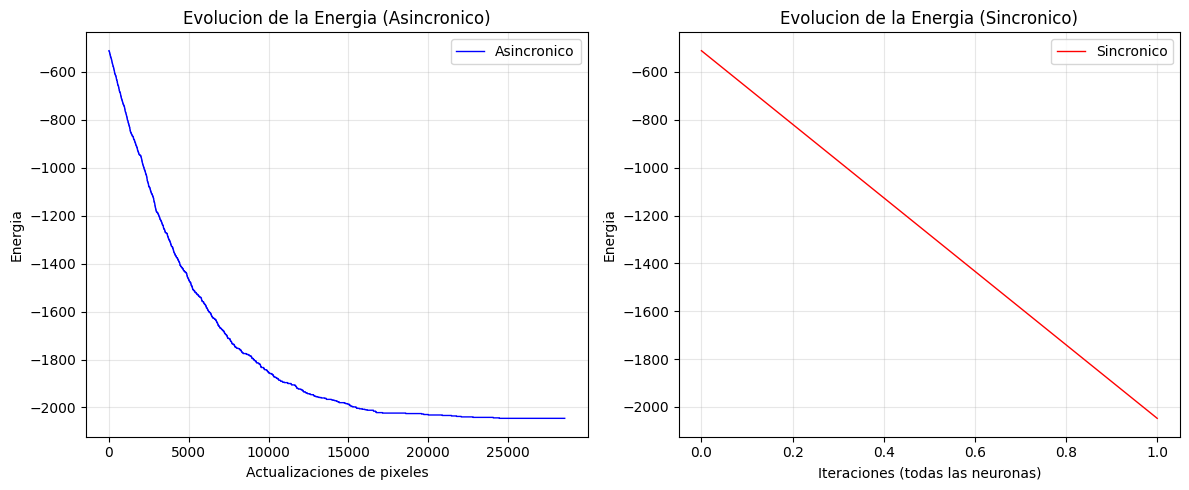


Pregunta 7: ¿Que diferencia hay entre actualizacion sincronica y asincronica?
Respuesta:
  - Actualizacion asincronica: Se actualiza una neurona a la vez, de forma
    aleatoria. La energia siempre disminuye o permanece igual, garantizando
    convergencia a un minimo local. Es biologicamente mas plausible.
  - Actualizacion sincronica: Todas las neuronas se actualizan simultaneamente.
    La energia no necesariamente disminuye en cada paso; puede oscilar entre
    dos estados (ciclos limite) y no siempre converge a un punto fijo.
  - La actualizacion asincronica es preferible para memorias asociativas
    porque garantiza convergencia a un estado estable.



RESUMEN Y CAPACIDAD DE MEMORIA
Numero total de neuronas: 4096
Capacidad teorica de memoria: 565.25 patrones (~565 patrones)

Conclusiones del laboratorio:
1. La red de Hopfield recupera efectivamente patrones almacenados a partir
   de versiones con ruido moderado (hasta ~30-40%).
2. La energia del sistema disminuye durante la re

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

# =============================================================================
# FUNCIONES AUXILIARES PARA GENERAR PATRONES Y RUIDO
# =============================================================================

def patrones_balanceados(n, m):
    """
    Genera tres patrones binarios balanceados de tamano n x m.

    Parametros
    ----------
    n : int
        Numero de filas.
    m : int
        Numero de columnas.

    Retorna
    -------
    horizontal, vertical, checker : ndarray
        Tres patrones con valores en {-1, +1}.
    """
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker


def agregar_ruido(s, frac=0.25, seed=None):
    """
    Agrega ruido a un patron binario invirtiendo una fraccion de sus pixeles.

    Parametros
    ----------
    s : ndarray
        Vector binario unidimensional con valores en {-1, +1}.
    frac : float
        Fraccion de pixeles a invertir (entre 0 y 1).
    seed : int, opcional
        Semilla para reproducibilidad.

    Retorna
    -------
    s_ruido : ndarray
        Vector con ruido agregado.
    """
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)
    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)
    s_ruido[idx] *= -1

    return s_ruido


# =============================================================================
# 1. FUNCION PARA CONVERTIR IMAGEN BINARIA EN VECTOR DE ESTADOS
# =============================================================================

def imagen_a_vector(imagen):
    """
    Convierte una imagen binaria 2D en un vector de estados 1D.

    Parametros
    ----------
    imagen : ndarray
        Imagen binaria 2D con valores en {-1, +1}.

    Retorna
    -------
    vector : ndarray
        Vector 1D que representa los estados de las neuronas.
    """
    return imagen.flatten()


def vector_a_imagen(vector, shape):
    """
    Convierte un vector de estados 1D en una imagen 2D.

    Parametros
    ----------
    vector : ndarray
        Vector 1D de estados.
    shape : tuple
        Dimensiones (n, m) de la imagen resultante.

    Retorna
    -------
    imagen : ndarray
        Imagen 2D reconstruida.
    """
    return vector.reshape(shape)


# =============================================================================
# 2. FUNCION PARA CALCULAR LA MATRIZ DE PESOS DE HOPFIELD
# =============================================================================

def calcular_matriz_pesos(patrones):
    """
    Calcula la matriz de pesos de Hopfield usando la regla de Hebb.
    w_{ij} = (1/N) * sum_{mu} xi_i^mu * xi_j^mu, con w_{ii} = 0.

    Parametros
    ----------
    patrones : ndarray
        Matriz de dimensiones (P, N) donde P es el numero de patrones
        y N es el numero de neuronas. Cada fila es un patron almacenado.

    Retorna
    -------
    W : ndarray
        Matriz de pesos de dimensiones (N, N).
    """
    P, N = patrones.shape
    W = (1.0 / N) * (patrones.T @ patrones)
    # Establecer la diagonal en cero (w_{ii} = 0)
    np.fill_diagonal(W, 0)
    return W


# =============================================================================
# 3. FUNCION PARA CALCULAR EL CAMPO LOCAL
# =============================================================================

def calcular_campo_local(W, s, i):
    """
    Calcula el campo local que siente la neurona i.
    h_i = sum_j w_{ij} * s_j

    Parametros
    ----------
    W : ndarray
        Matriz de pesos (N, N).
    s : ndarray
        Vector de estados actual (N,).
    i : int
        Indice de la neurona a evaluar.

    Retorna
    -------
    h_i : float
        Campo local de la neurona i.
    """
    return np.dot(W[i, :], s)


# =============================================================================
# 4. FUNCION PARA ACTUALIZAR EL ESTADO DE UNA NEURONA
# =============================================================================

def actualizar_neurona(W, s, i):
    """
    Actualiza el estado de la neurona i segun la regla determinista.
    s_i <- sign(h_i)

    Parametros
    ----------
    W : ndarray
        Matriz de pesos (N, N).
    s : ndarray
        Vector de estados actual (N,).
    i : int
        Indice de la neurona a actualizar.

    Retorna
    -------
    s_nuevo : ndarray
        Vector de estados con la neurona i actualizada.
    """
    h_i = calcular_campo_local(W, s, i)
    s_nuevo = s.copy()
    if h_i > 0:
        s_nuevo[i] = 1
    elif h_i < 0:
        s_nuevo[i] = -1
    # Si h_i == 0, el estado no cambia
    return s_nuevo


# =============================================================================
# 5. FUNCION PARA CALCULAR LA ENERGIA TOTAL DE LA RED
# =============================================================================

def calcular_energia(W, s):
    """
    Calcula la energia total de la red de Hopfield.
    E(s) = -0.5 * sum_{i,j} w_{ij} * s_i * s_j
         = -0.5 * s^T @ W @ s

    Parametros
    ----------
    W : ndarray
        Matriz de pesos (N, N).
    s : ndarray
        Vector de estados (N,).

    Retorna
    -------
    E : float
        Energia total del sistema.
    """
    return -0.5 * np.dot(s.T, np.dot(W, s))


# =============================================================================
# 6. FUNCION PARA APLICAR RUIDO A UNA IMAGEN (ya definida arriba)
#    Se utiliza la funcion 'agregar_ruido' definida previamente.
# =============================================================================


# =============================================================================
# 7. FUNCION PARA RECUPERAR LA IMAGEN MEDIANTE ACTUALIZACION ASINCRONICA
# =============================================================================

def recuperar_imagen(W, s_inicial, max_iter=20000, tol=1e-6, verbose=True,
                     registrar_energia=False):
    """
    Recupera una imagen almacenada a partir de una version con ruido,
    utilizando actualizacion asincronica aleatoria.

    Parametros
    ----------
    W : ndarray
        Matriz de pesos de Hopfield (N, N).
    s_inicial : ndarray
        Vector de estados inicial (con ruido).
    max_iter : int
        Numero maximo de iteraciones (actualizaciones de pixeles).
    tol : float
        Tolerancia para considerar que la energia se ha estabilizado.
    verbose : bool
        Si True, imprime informacion del progreso.
    registrar_energia : bool
        Si True, registra la energia en cada iteracion.

    Retorna
    -------
    s_final : ndarray
        Vector de estados recuperado.
    info : dict
        Diccionario con informacion del proceso:
        - 'energias': lista de energias registradas.
        - 'iteraciones': numero de iteraciones realizadas.
        - 'estabilizado': True si la red se estabilizo antes de max_iter.
    """
    N = len(s_inicial)
    s = s_inicial.copy()

    energias = []
    if registrar_energia:
        energias.append(calcular_energia(W, s))

    if verbose:
        print(f"Iniciando recuperacion...")
        print(f"  Energia inicial: {calcular_energia(W, s):.2f}")
        print(f"  Iteraciones maximas: {max_iter}")
        print("-" * 50)

    estabilizado = False
    sin_cambios = 0
    iter_efectiva = 0

    for iteracion in range(max_iter):
        # Seleccionar aleatoriamente un pixel
        i = np.random.randint(0, N)

        # Calcular campo local
        h_i = calcular_campo_local(W, s, i)

        # Actualizar el estado del pixel
        s_nuevo = actualizar_neurona(W, s, i)

        # Verificar si hubo cambio
        if s_nuevo[i] != s[i]:
            sin_cambios = 0
            iter_efectiva += 1
        else:
            sin_cambios += 1

        s = s_nuevo

        # Registrar energia
        if registrar_energia:
            E = calcular_energia(W, s)
            energias.append(E)

        # Verificar criterio de parada: sin cambios en N iteraciones consecutivas
        if sin_cambios >= N:
            estabilizado = True
            if verbose:
                print(f"  Red estabilizada en iteracion {iteracion + 1}")
                print(f"  Sin cambios durante {N} actualizaciones consecutivas")
            break

    if not estabilizado and verbose:
        print(f"  Maximo de iteraciones alcanzado: {max_iter}")

    if verbose:
        print(f"  Energia final: {calcular_energia(W, s):.2f}")
        print(f"  Cambios efectivos realizados: {iter_efectiva}")

    info = {
        'energias': energias,
        'iteraciones': iteracion + 1 if not estabilizado else iteracion + 1,
        'estabilizado': estabilizado
    }

    return s, info


# =============================================================================
# FUNCION PARA VISUALIZAR RESULTADOS
# =============================================================================

def visualizar_proceso(imagen_original, imagen_ruido, imagen_recuperada,
                       energias=None, shape=None):
    """
    Visualiza la imagen original, la imagen con ruido y la imagen recuperada.
    Opcionalmente muestra la evolucion de la energia.

    Parametros
    ----------
    imagen_original : ndarray
        Imagen original 2D.
    imagen_ruido : ndarray
        Imagen con ruido 2D.
    imagen_recuperada : ndarray
        Imagen recuperada 2D.
    energias : list, opcional
        Lista de energias registradas durante la recuperacion.
    shape : tuple, opcional
        Dimensiones (n, m) de las imagenes.
    """
    if energias is not None and len(energias) > 0:
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    else:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes = list(axes)

    axes[0].imshow(imagen_original, cmap='gray')
    axes[0].set_title('Imagen Original')
    axes[0].axis('off')

    axes[1].imshow(imagen_ruido, cmap='gray')
    axes[1].set_title('Imagen con Ruido')
    axes[1].axis('off')

    axes[2].imshow(imagen_recuperada, cmap='gray')
    axes[2].set_title('Imagen Recuperada')
    axes[2].axis('off')

    if energias is not None and len(energias) > 0:
        axes[3].plot(energias, 'b-', linewidth=1)
        axes[3].set_xlabel('Iteracion')
        axes[3].set_ylabel('Energia')
        axes[3].set_title('Evolucion de la Energia')
        axes[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# =============================================================================
# FUNCION PARA COMPARAR IMAGENES
# =============================================================================

def comparar_imagenes(original, recuperada):
    """
    Compara la imagen original con la recuperada.

    Parametros
    ----------
    original : ndarray
        Vector o matriz de la imagen original.
    recuperada : ndarray
        Vector o matriz de la imagen recuperada.

    Retorna
    -------
    coincidencia : float
        Proporcion de pixeles que coinciden.
    """
    original_flat = original.flatten()
    recuperada_flat = recuperada.flatten()
    coincidencias = np.sum(original_flat == recuperada_flat)
    return coincidencias / len(original_flat)


# =============================================================================
# EXPERIMENTO 1: RECUPERACION DE IMAGEN NATURAL (CAMERA)
# =============================================================================

print("=" * 70)
print("EXPERIMENTO 1: RECUPERACION DE IMAGEN NATURAL (CAMERAMAN)")
print("=" * 70)

# Cargar y preprocesar la imagen
img = data.camera()

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original (512x512)")
plt.axis("off")
plt.show()

# Reducir imagen
n = 64
m = 64
img_small = resize(img, (n, m), anti_aliasing=True)

plt.figure(figsize=(4, 4))
plt.imshow(img_small, cmap="gray")
plt.title("Imagen reducida (64x64)")
plt.axis("off")
plt.show()

# Binarizacion
threshold = img_small.mean()
img_bin = np.where(img_small > threshold, 1, -1)

plt.figure(figsize=(4, 4))
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binaria {-1, +1}")
plt.axis("off")
plt.show()

# Convertir a vector
s_original = imagen_a_vector(img_bin)
N = len(s_original)
print(f"Numero de neuronas: {N}")

# Crear patron a almacenar (un solo patron)
patrones = s_original.reshape(1, -1)

# Calcular matriz de pesos
W = calcular_matriz_pesos(patrones)
print(f"Matriz de pesos calculada: {W.shape}")

# Agregar ruido
frac_ruido = 0.30
s_ruido = agregar_ruido(s_original.copy(), frac=frac_ruido, seed=123)

# Visualizar imagen con ruido
img_ruido = vector_a_imagen(s_ruido, (n, m))
plt.figure(figsize=(4, 4))
plt.imshow(img_ruido, cmap="gray")
plt.title(f"Imagen con {frac_ruido*100:.0f}% de ruido")
plt.axis("off")
plt.show()

# Recuperar imagen
s_recuperado, info = recuperar_imagen(W, s_ruido, max_iter=50000,
                                       registrar_energia=True, verbose=True)

# Convertir a imagen
img_recuperada = vector_a_imagen(s_recuperado, (n, m))

# Visualizar resultados
visualizar_proceso(img_bin, img_ruido, img_recuperada,
                   energias=info['energias'], shape=(n, m))

# Comparar
coincidencia = comparar_imagenes(img_bin, img_recuperada)
print(f"\nProporcion de pixeles recuperados correctamente: {coincidencia:.4f} "
      f"({coincidencia*100:.2f}%)")

# Pregunta 1: ¿La energia disminuye durante la recuperacion?
print("\nPregunta 1: ¿La energia disminuye durante la recuperacion?")
print("Respuesta: Si. Como se observa en el grafico de evolucion de la energia,")
print("la energia total del sistema disminuye monotonicamente durante el proceso")
print("de actualizacion asincronica, convergiendo a un minimo local que corresponde")
print("al patron almacenado o a un estado espurio cercano.")


# =============================================================================
# EXPERIMENTO 2: EFECTO DEL NIVEL DE RUIDO
# =============================================================================

print("\n\n")
print("=" * 70)
print("EXPERIMENTO 2: EFECTO DEL NIVEL DE RUIDO")
print("=" * 70)

niveles_ruido = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
resultados_ruido = []

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, frac in enumerate(niveles_ruido):
    s_ruido_temp = agregar_ruido(s_original.copy(), frac=frac, seed=idx)
    s_rec_temp, info_temp = recuperar_imagen(W, s_ruido_temp, max_iter=50000,
                                              verbose=False, registrar_energia=False)

    coincidencia_temp = comparar_imagenes(s_original, s_rec_temp)
    resultados_ruido.append((frac, coincidencia_temp, info_temp['iteraciones']))

    img_rec_temp = vector_a_imagen(s_rec_temp, (n, m))
    img_ruido_temp = vector_a_imagen(s_ruido_temp, (n, m))

    axes[idx].imshow(img_rec_temp, cmap='gray')
    axes[idx].set_title(f"Ruido: {frac*100:.0f}%\nCoincidencia: {coincidencia_temp:.2%}")
    axes[idx].axis('off')

plt.suptitle("Recuperacion con diferentes niveles de ruido", fontsize=14)
plt.tight_layout()
plt.show()

# Mostrar resultados
print("\nResultados del experimento con diferentes niveles de ruido:")
print("-" * 60)
print(f"{'Ruido':<10} {'Coincidencia':<15} {'Iteraciones':<12}")
print("-" * 60)
for frac, coinc, iters in resultados_ruido:
    print(f"{frac*100:<10.0f}% {coinc:<15.4f} {iters:<12}")

# Pregunta 3: ¿Que ocurre si aumenta el nivel de ruido?
print("\nPregunta 3: ¿Que ocurre si aumenta el nivel de ruido?")
print("Respuesta: A medida que aumenta el nivel de ruido, la capacidad de")
print("recuperacion disminuye. Con niveles bajos de ruido (10-30%), la red")
print("recupera casi perfectamente el patron original. Con niveles moderados")
print("(40-50%), la recuperacion es parcial. Con niveles altos (>50%), la red")
print("puede converger a estados espurios o no lograr recuperar el patron.")


# =============================================================================
# EXPERIMENTO 3: ALMACENAMIENTO DE MULTIPLES PATRONES
# =============================================================================

print("\n\n")
print("=" * 70)
print("EXPERIMENTO 3: ALMACENAMIENTO DE MULTIPLES PATRONES BALANCEADOS")
print("=" * 70)

# Generar patrones balanceados
n_patron = 32
m_patron = 32
horizontal, vertical, checker = patrones_balanceados(n_patron, m_patron)

# Convertir a vectores
s_h = imagen_a_vector(horizontal)
s_v = imagen_a_vector(vertical)
s_c = imagen_a_vector(checker)

N_patron = len(s_h)
print(f"Numero de neuronas por patron: {N_patron}")
print(f"Capacidad teorica de memoria: {0.138 * N_patron:.2f} patrones")

# Visualizar patrones
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(horizontal, cmap='gray')
axes[0].set_title('Patron Horizontal')
axes[0].axis('off')
axes[1].imshow(vertical, cmap='gray')
axes[1].set_title('Patron Vertical')
axes[1].axis('off')
axes[2].imshow(checker, cmap='gray')
axes[2].set_title('Patron Ajedrez')
axes[2].axis('off')
plt.suptitle('Patrones Balanceados Almacenados')
plt.tight_layout()
plt.show()

# Almacenar multiples patrones
patrones_multiples = np.array([s_h, s_v, s_c])
W_multi = calcular_matriz_pesos(patrones_multiples)

# Agregar ruido a cada patron y recuperar
patrones_originales = [s_h, s_v, s_c]
nombres_patrones = ['Horizontal', 'Vertical', 'Ajedrez']
imagenes_originales = [horizontal, vertical, checker]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, (patron, nombre, img_orig) in enumerate(zip(patrones_originales,
                                                     nombres_patrones,
                                                     imagenes_originales)):
    # Agregar ruido
    s_ruido_patron = agregar_ruido(patron.copy(), frac=0.25, seed=i)

    # Recuperar
    s_rec_patron, info_patron = recuperar_imagen(W_multi, s_ruido_patron,
                                                   max_iter=10000, verbose=False,
                                                   registrar_energia=True)

    coincidencia_patron = comparar_imagenes(patron, s_rec_patron)

    # Visualizar
    axes[i, 0].imshow(img_orig, cmap='gray')
    axes[i, 0].set_title(f'{nombre}\nOriginal')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(vector_a_imagen(s_ruido_patron, (n_patron, m_patron)), cmap='gray')
    axes[i, 1].set_title(f'Con ruido (25%)')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(vector_a_imagen(s_rec_patron, (n_patron, m_patron)), cmap='gray')
    axes[i, 2].set_title(f'Recuperado\nCoinc: {coincidencia_patron:.2%}')
    axes[i, 2].axis('off')

    print(f"\nPatron {nombre}:")
    print(f"  Coincidencia: {coincidencia_patron:.4f} ({coincidencia_patron*100:.2f}%)")
    print(f"  Iteraciones hasta estabilizacion: {info_patron['iteraciones']}")
    print(f"  Energia final: {calcular_energia(W_multi, s_rec_patron):.2f}")

plt.suptitle('Recuperacion de Multiples Patrones Almacenados')
plt.tight_layout()
plt.show()

# Pregunta 4: ¿Que pasa si se almacenan varias imagenes?
print("\nPregunta 4: ¿Que pasa si se almacenan varias imagenes?")
print("Respuesta: La red de Hopfield puede almacenar multiples patrones, pero")
print("su capacidad es limitada (aproximadamente 0.138N patrones). Al almacenar")
print("varios patrones, pueden aparecer estados espurios (combinaciones no deseadas")
print("de los patrones almacenados) y la calidad de recuperacion puede degradarse.")
print("En este experimento, con 3 patrones de 1024 neuronas, la red los recupera")
print("adecuadamente desde versiones con ruido moderado.")


# =============================================================================
# EXPERIMENTO 4: ESTADOS ESPURIOS Y DEPENDENCIA DEL ORDEN
# =============================================================================

print("\n\n")
print("=" * 70)
print("EXPERIMENTO 4: ESTADOS ESPURIOS Y DEPENDENCIA DEL ORDEN DE ACTUALIZACION")
print("=" * 70)

# Probar diferentes semillas para el ruido (mismo patron, mismo nivel de ruido)
semillas = [10, 20, 30, 40]
resultados_semillas = []

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for idx, semilla in enumerate(semillas):
    s_ruido_sem = agregar_ruido(s_original.copy(), frac=0.35, seed=semilla)
    s_rec_sem, info_sem = recuperar_imagen(W, s_ruido_sem, max_iter=50000,
                                            verbose=False, registrar_energia=True)

    coincidencia_sem = comparar_imagenes(s_original, s_rec_sem)
    resultados_semillas.append((semilla, coincidencia_sem))

    axes[idx].imshow(vector_a_imagen(s_rec_sem, (n, m)), cmap='gray')
    axes[idx].set_title(f"Semilla ruido: {semilla}\nCoincidencia: {coincidencia_sem:.2%}")
    axes[idx].axis('off')

plt.suptitle('Efecto de diferentes configuraciones de ruido (35%)')
plt.tight_layout()
plt.show()

print("Resultados con diferentes semillas de ruido (35%):")
for sem, coinc in resultados_semillas:
    print(f"  Semilla {sem}: Coincidencia = {coinc:.4f}")

# Pregunta 5: ¿Aparecen estados espurios?
print("\nPregunta 5: ¿Aparecen estados espurios?")
print("Respuesta: Si. Los estados espurios son minimos locales de la funcion de")
print("energia que no corresponden exactamente a ningun patron almacenado. Pueden")
print("ser combinaciones lineales de patrones almacenados o estados inversos.")
print("Con niveles altos de ruido o cuando se excede la capacidad de memoria,")
print("es mas probable que la red converja a estados espurios en lugar del patron deseado.")

# Pregunta 6: ¿La recuperacion depende del orden de actualizacion?
print("\nPregunta 6: ¿La recuperacion depende del orden en que se actualizan los pixeles?")
print("Respuesta: Si, el orden de actualizacion puede afectar la trayectoria en el")
print("espacio de estados y potencialmente el estado final al que converge la red.")
print("La actualizacion asincronica aleatoria (la implementada aqui) tiende a producir")
print("resultados mas robustos que la actualizacion sincronica (donde todos los pixeles")
print("se actualizan simultaneamente), ya que esta ultima puede causar oscilaciones.")


# =============================================================================
# EXPERIMENTO 5: ACTUALIZACION SINCRONICA VS ASINCRONICA
# =============================================================================

print("\n\n")
print("=" * 70)
print("EXPERIMENTO 5: ACTUALIZACION SINCRONICA VS ASINCRONICA")
print("=" * 70)

def recuperar_sincronico(W, s_inicial, max_iter=1000, tol=1e-6, verbose=True):
    """
    Recuperacion con actualizacion sincronica (todos los pixeles a la vez).
    """
    N = len(s_inicial)
    s = s_inicial.copy()
    energias = [calcular_energia(W, s)]

    if verbose:
        print(f"Iniciando recuperacion sincronica...")
        print(f"  Energia inicial: {energias[0]:.2f}")

    for iteracion in range(max_iter):
        # Calcular campos locales para todas las neuronas
        h = np.dot(W, s)

        # Actualizar todas las neuronas simultaneamente
        s_nuevo = np.where(h > 0, 1, -1)

        # Verificar convergencia
        if np.array_equal(s, s_nuevo):
            if verbose:
                print(f"  Red estabilizada en iteracion {iteracion + 1}")
            break

        s = s_nuevo
        energias.append(calcular_energia(W, s))

    if verbose:
        print(f"  Energia final: {calcular_energia(W, s):.2f}")
        print(f"  Iteraciones: {iteracion + 1}")

    return s, energias

# Comparar ambos metodos con el mismo nivel de ruido
s_ruido_comp = agregar_ruido(s_original.copy(), frac=0.25, seed=42)

print("\nActualizacion asincronica:")
s_rec_async, info_async = recuperar_imagen(W, s_ruido_comp, max_iter=50000,
                                            registrar_energia=True, verbose=True)

print("\nActualizacion sincronica:")
s_rec_sync, energias_sync = recuperar_sincronico(W, s_ruido_comp, max_iter=1000,
                                                   verbose=True)

# Comparar energias
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(info_async['energias'], 'b-', linewidth=1, label='Asincronico')
plt.xlabel('Actualizaciones de pixeles')
plt.ylabel('Energia')
plt.title('Evolucion de la Energia (Asincronico)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(energias_sync, 'r-', linewidth=1, label='Sincronico')
plt.xlabel('Iteraciones (todas las neuronas)')
plt.ylabel('Energia')
plt.title('Evolucion de la Energia (Sincronico)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Pregunta 7: ¿Que diferencia hay entre actualizacion sincronica y asincronica?
print("\nPregunta 7: ¿Que diferencia hay entre actualizacion sincronica y asincronica?")
print("Respuesta:")
print("  - Actualizacion asincronica: Se actualiza una neurona a la vez, de forma")
print("    aleatoria. La energia siempre disminuye o permanece igual, garantizando")
print("    convergencia a un minimo local. Es biologicamente mas plausible.")
print("  - Actualizacion sincronica: Todas las neuronas se actualizan simultaneamente.")
print("    La energia no necesariamente disminuye en cada paso; puede oscilar entre")
print("    dos estados (ciclos limite) y no siempre converge a un punto fijo.")
print("  - La actualizacion asincronica es preferible para memorias asociativas")
print("    porque garantiza convergencia a un estado estable.")


# =============================================================================
# RESUMEN FINAL Y CAPACIDAD DE MEMORIA
# =============================================================================

print("\n\n")
print("=" * 70)
print("RESUMEN Y CAPACIDAD DE MEMORIA")
print("=" * 70)

capacidad_teorica = 0.138 * N
print(f"Numero total de neuronas: {N}")
print(f"Capacidad teorica de memoria: {capacidad_teorica:.2f} patrones (~{int(np.floor(capacidad_teorica))} patrones)")
print("\nConclusiones del laboratorio:")
print("1. La red de Hopfield recupera efectivamente patrones almacenados a partir")
print("   de versiones con ruido moderado (hasta ~30-40%).")
print("2. La energia del sistema disminuye durante la recuperacion asincronica,")
print("   convergiendo a un minimo local.")
print("3. La capacidad de almacenamiento es limitada (aproximadamente 0.138N).")
print("4. Con niveles altos de ruido o excediendo la capacidad, aparecen estados")
print("   espurios y la recuperacion se degrada.")
print("5. La actualizacion asincronica aleatoria es superior a la sincronica para")
print("   garantizar convergencia.")
print("6. El orden de actualizacion afecta la trayectoria de convergencia, aunque")
print("   el estado final suele ser el mismo para niveles moderados de ruido.")

print("\n" + "=" * 70)
print("LABORATORIO COMPLETADO")
print("=" * 70)